# Formula SAE Telemetry Analyzer

Exploratory analysis of synthetic Formula SAE-style telemetry.

**All data here is synthetic.** It is generated by `src/generate_telemetry.py`
and does not come from any real vehicle or team. Two sessions carry
deliberately injected faults so the vehicle-health checks can be validated
against a known answer: S04 has degraded cooling, S06 has a weak battery cell.

This notebook explores the data visually. The analysis logic lives in `src/`;
nothing is reimplemented here.

In [1]:
import os
import sys

# Modules in src/ use paths relative to the project root, so move there.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import consistency_metrics, health_report
from src.database import run_query
from src.lap_comparison import compare_laps
from src.run_sql import run_named_query

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Loaded.")

Loaded.


## 1. Session overview

Six sessions, eight laps each. The sessions differ in ambient temperature,
driver aggression, and driver consistency.

In [2]:
sessions = run_named_query("session_summary")
sessions[["session_id", "label", "ambient_temp_c", "driver_aggression",
          "best_lap_s", "avg_lap_s", "top_speed_kmh"]]

,session_id,label,ambient_temp_c,driver_aggression,best_lap_s,avg_lap_s,top_speed_kmh
0,S05,Push session,24.0,1.06,55.3,55.66,112.9
1,S06,Weak cell under load,23.0,1.03,56.1,56.70,112.9
2,S03,Hot afternoon running,33.0,1.02,56.4,57.01,112.9
3,S04,Cooling system degraded,29.0,1.01,56.9,57.61,112.9
4,S02,Baseline practice,21.0,1.00,57.7,58.21,112.9
5,S01,Cool morning shakedown,16.0,0.94,60.8,61.26,111.9


## 2. Lap time distribution

Each session's laps, with the out-lap included. Lap 1 always starts from a
standstill, which is why it sits clear of the rest in every session.

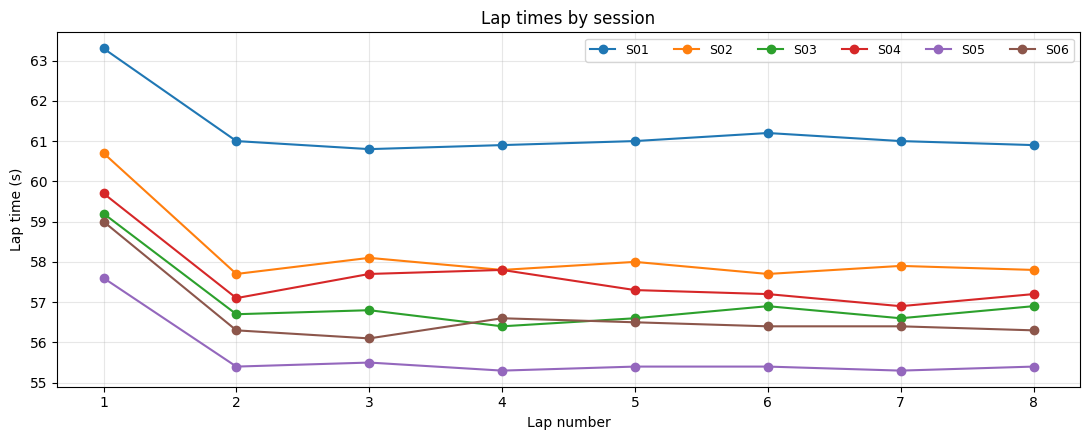

In [3]:
laps = run_query("SELECT session_id, lap_number, lap_time_s FROM laps")

fig, ax = plt.subplots()
for session_id, group in laps.groupby("session_id"):
    ax.plot(group["lap_number"], group["lap_time_s"], marker="o", label=session_id)

ax.set_xlabel("Lap number")
ax.set_ylabel("Lap time (s)")
ax.set_title("Lap times by session")
ax.legend(ncol=6, fontsize=9)
plt.tight_layout()

The spread within each session is what the consistency metric measures.
Standard deviation is taken with the out-lap excluded, since a standing start
would otherwise dominate it.

,session_id,laps_counted,mean_lap_s,std_dev_s,range_s,variation_pct
0,S05,7,55.39,0.069,0.2,0.125
1,S01,7,60.97,0.125,0.4,0.205
2,S02,7,57.86,0.151,0.4,0.261
3,S06,7,56.37,0.160,0.5,0.284
4,S03,7,56.70,0.183,0.5,0.323
5,S04,7,57.31,0.324,0.9,0.565


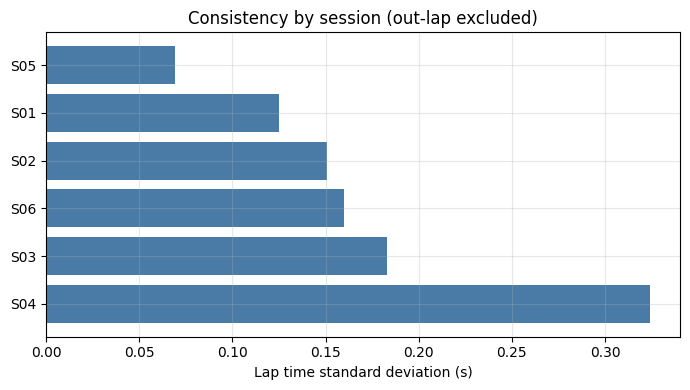

In [4]:
consistency = consistency_metrics()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(consistency["session_id"], consistency["std_dev_s"], color="#4a7ba7")
ax.set_xlabel("Lap time standard deviation (s)")
ax.set_title("Consistency by session (out-lap excluded)")
ax.invert_yaxis()
plt.tight_layout()

consistency

## 3. Speed over distance

One lap of the baseline session. The track's eight sections are shaded so the
speed trace can be read against the layout: the car is quickest on the Long
Straight and slowest through the Hairpin.

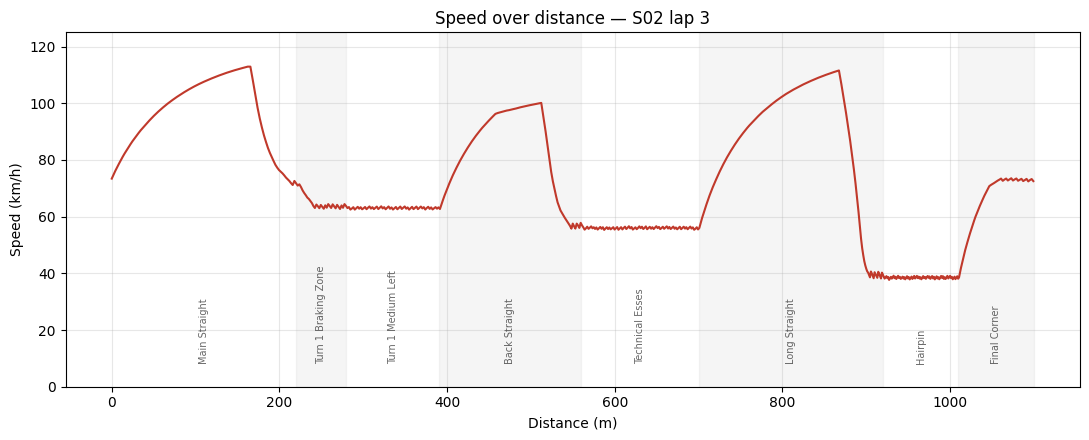

In [5]:
from src.track import TRACK_SECTIONS

lap = run_query(
    "SELECT distance_m, speed_kmh, throttle_pct, brake_pressure_pct, rpm "
    "FROM telemetry WHERE session_id = 'S02' AND lap_number = 3 "
    "ORDER BY distance_m"
)

fig, ax = plt.subplots()

for i, section in enumerate(TRACK_SECTIONS):
    ax.axvspan(section["start_m"], section["end_m"],
               alpha=0.08, color="grey" if i % 2 else "white")
    ax.text((section["start_m"] + section["end_m"]) / 2, 8,
            section["name"], rotation=90, fontsize=7,
            ha="center", va="bottom", alpha=0.6)

ax.plot(lap["distance_m"], lap["speed_kmh"], color="#c0392b", linewidth=1.5)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Speed over distance — S02 lap 3")
ax.set_ylim(0, 125)
plt.tight_layout()

## 4. Driver inputs

Throttle and brake over the same lap. Braking happens at the *end* of straights,
before the corner — not in it. That is the lookahead in the driver model
working: it scans ahead, sees a slower section coming, and lifts early.

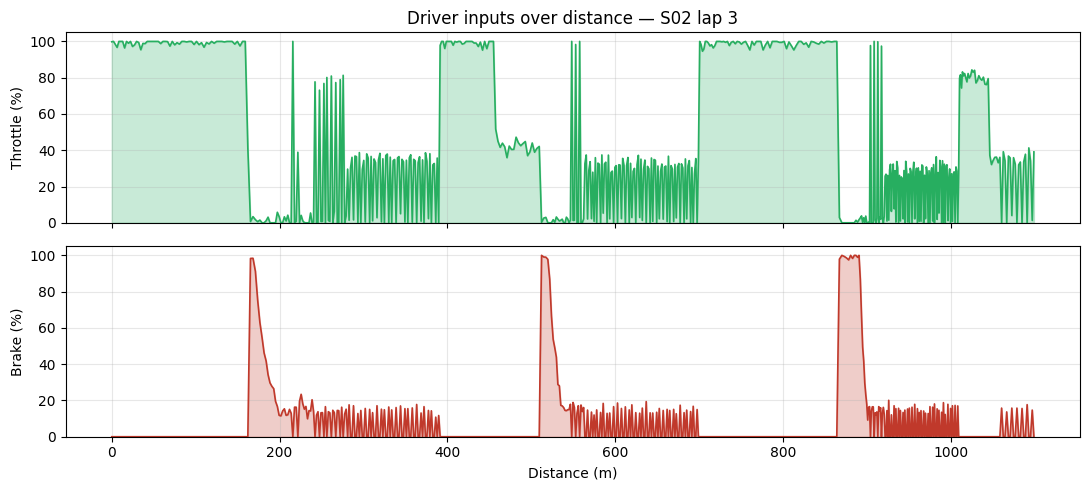

In [11]:
fig, (ax_t, ax_b) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax_t.plot(lap["distance_m"], lap["throttle_pct"],
          color="#27ae60", linewidth=1.2)
ax_t.fill_between(lap["distance_m"], 0, lap["throttle_pct"],
                  color="#27ae60", alpha=0.25)
ax_t.set_ylabel("Throttle (%)")
ax_t.set_ylim(0, 105)
ax_t.set_title("Driver inputs over distance — S02 lap 3")

ax_b.plot(lap["distance_m"], lap["brake_pressure_pct"],
          color="#c0392b", linewidth=1.2)
ax_b.fill_between(lap["distance_m"], 0, lap["brake_pressure_pct"],
                  color="#c0392b", alpha=0.25)
ax_b.set_ylabel("Brake (%)")
ax_b.set_ylim(0, 105)
ax_b.set_xlabel("Distance (m)")

plt.tight_layout()

## 5. Lap comparison

The fastest and slowest laps of the baseline session, aligned onto a common
distance grid. Two laps have different sample counts because they took
different amounts of time, so they cannot be compared sample by sample —
both are interpolated onto the same distance axis first.

The lower panel is the cumulative time delta. Where it rises, the slower lap
is losing time; where it is flat, the two laps are even.

Final delta: +0.400 s


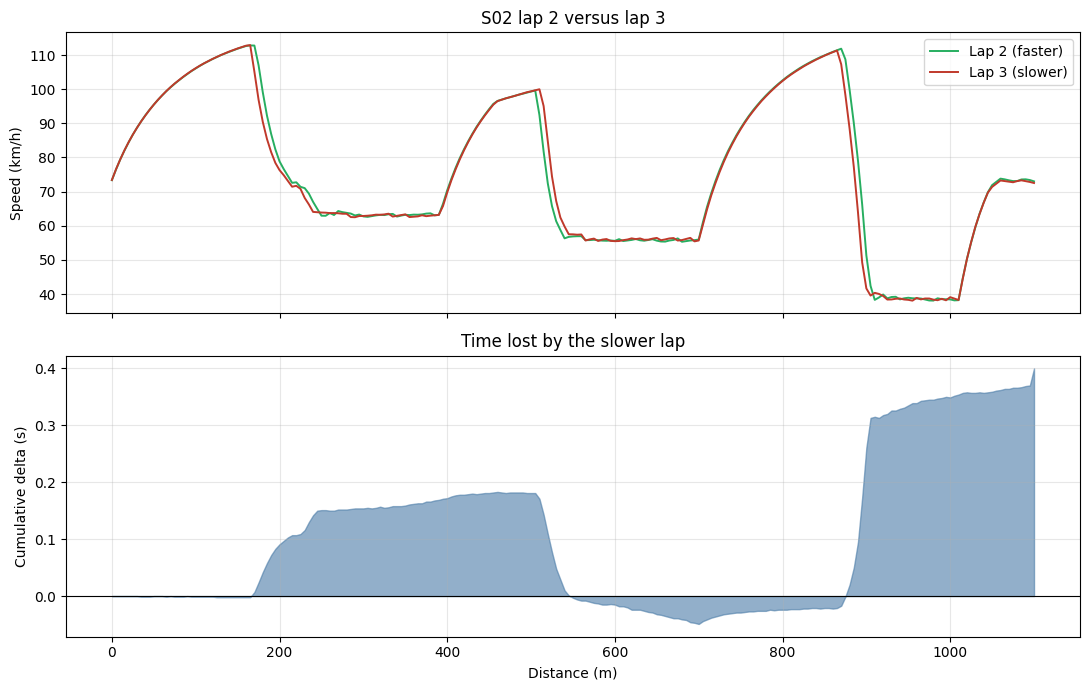

In [7]:
best_worst = run_query(
    "SELECT lap_number, lap_time_s FROM laps "
    "WHERE session_id = 'S02' AND lap_number > 1 ORDER BY lap_time_s"
)
fast = int(best_worst.iloc[0]["lap_number"])
slow = int(best_worst.iloc[-1]["lap_number"])

comp = compare_laps("S02", fast, "S02", slow)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(comp["distance_m"], comp["speed_a_kmh"],
         label=f"Lap {fast} (faster)", color="#27ae60", linewidth=1.4)
ax1.plot(comp["distance_m"], comp["speed_b_kmh"],
         label=f"Lap {slow} (slower)", color="#c0392b", linewidth=1.4)
ax1.set_ylabel("Speed (km/h)")
ax1.set_title(f"S02 lap {fast} versus lap {slow}")
ax1.legend()

ax2.fill_between(comp["distance_m"], 0, comp["time_delta_s"],
                 color="#4a7ba7", alpha=0.6)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Distance (m)")
ax2.set_ylabel("Cumulative delta (s)")
ax2.set_title("Time lost by the slower lap")

plt.tight_layout()

print(f"Final delta: {comp['time_delta_s'].iloc[-1]:+.3f} s")

## 6. Temperature across a session

Powertrain temperature over the whole of each session. A healthy car heats up
early and then levels off as cooling catches up with heat production. S04 does
not level off, which is the seeded cooling fault.

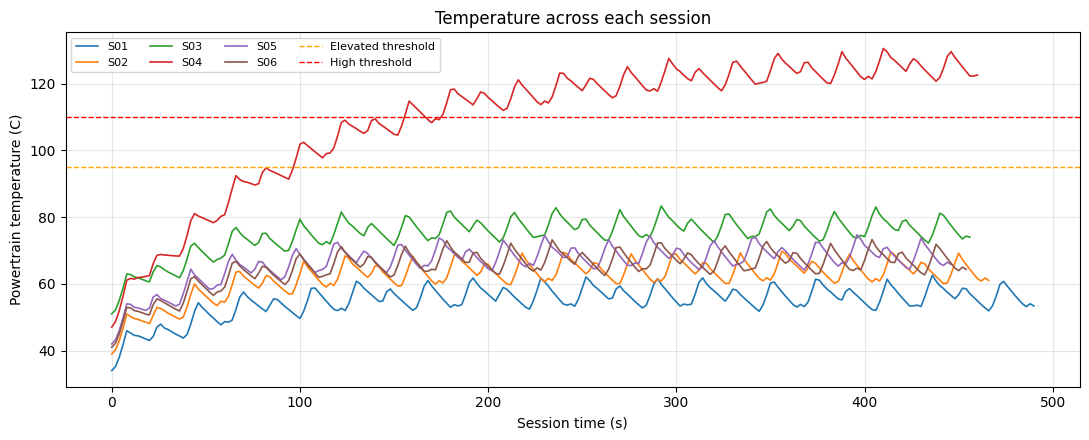

In [8]:
temps = run_query(
    "SELECT session_id, session_time_s, powertrain_temp_c FROM telemetry "
    "ORDER BY session_id, session_time_s"
)

fig, ax = plt.subplots()
for session_id, group in temps.groupby("session_id"):
    thinned = group.iloc[::20]
    ax.plot(thinned["session_time_s"], thinned["powertrain_temp_c"],
            label=session_id, linewidth=1.2)

ax.axhline(95, color="orange", linestyle="--", linewidth=1,
           label="Elevated threshold")
ax.axhline(110, color="red", linestyle="--", linewidth=1,
           label="High threshold")
ax.set_xlabel("Session time (s)")
ax.set_ylabel("Powertrain temperature (C)")
ax.set_title("Temperature across each session")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()

Absolute temperature alone would partly conflate a hot day with a cooling
problem. Temperature *rise over ambient* separates them: S03 ran on the hottest
day in the set and still shows one of the smaller rises.

,session_id,ambient_temp_c,peak_temp_c,temp_rise_over_ambient_c,seeded_fault,overall_status
0,S01,16.0,62.7,46.7,None,OK
1,S02,21.0,70.5,49.5,None,OK
2,S03,33.0,83.4,50.4,None,OK
3,S04,29.0,131.0,101.9,cooling,ATTENTION
4,S05,24.0,74.9,50.9,None,OK
5,S06,23.0,73.4,50.3,battery,ATTENTION


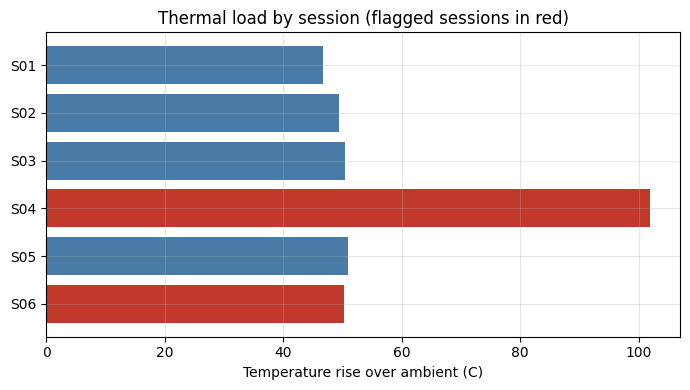

In [9]:
health = health_report()

fig, ax = plt.subplots(figsize=(7, 4))
colours = ["#c0392b" if s != "OK" else "#4a7ba7"
           for s in health["overall_status"]]
ax.barh(health["session_id"], health["temp_rise_over_ambient_c"], color=colours)
ax.set_xlabel("Temperature rise over ambient (C)")
ax.set_title("Thermal load by session (flagged sessions in red)")
ax.invert_yaxis()
plt.tight_layout()

health[["session_id", "ambient_temp_c", "peak_temp_c",
        "temp_rise_over_ambient_c", "seeded_fault", "overall_status"]]

## 7. Voltage under load

Pack voltage sags under load because of internal resistance and recovers when
the load comes off. Comparing loaded against unloaded voltage *within* a session
controls for state of charge, so what is left is the pack's internal resistance.

S06 sags roughly twice as hard as the rest, which is the seeded weak cell.

,session_id,seeded_fault,avg_v_coasting,avg_v_under_load,sag_v
0,S06,battery,395.85,372.51,23.34
1,S05,None,395.97,384.82,11.15
2,S03,None,395.98,384.86,11.12
3,S04,cooling,395.99,384.93,11.07
4,S02,None,395.97,384.94,11.03
5,S01,None,395.95,385.10,10.85


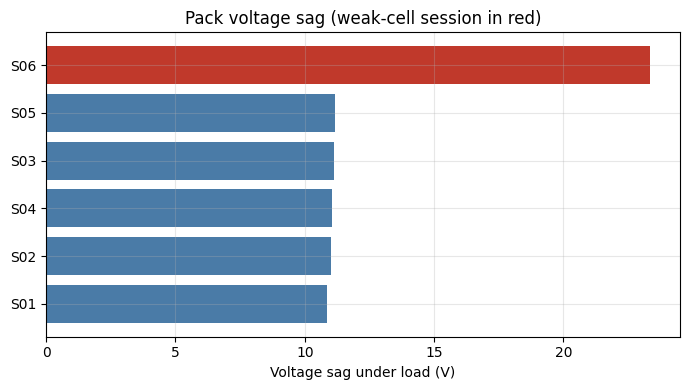

In [10]:
sag = run_named_query("voltage_sag_under_load")

fig, ax = plt.subplots(figsize=(7, 4))
colours = ["#c0392b" if f == "battery" else "#4a7ba7"
           for f in sag["seeded_fault"].fillna("")]
ax.barh(sag["session_id"], sag["sag_v"], color=colours)
ax.set_xlabel("Voltage sag under load (V)")
ax.set_title("Pack voltage sag (weak-cell session in red)")
ax.invert_yaxis()
plt.tight_layout()

sag

## Notes and limitations

- Lap time is **counted** from simulation timesteps, never generated. A faster
  lap covers more distance per step and so needs fewer steps.
- The distance-aligned comparison reconciles with the lap-time table exactly,
  which is what shows the interpolation is correct.
- **Theoretical best lap** (sum of each session's best sector times) sits within
  ±0.2 s of the actual best lap for every session. Sector times are
  reconstructed from 10 Hz samples and so carry about 0.1 s of quantisation
  each, and the simulated driver's sector-to-sector variation happens to be a
  similar size. The query is correct; the simulation does not produce enough
  sector-level variation for the metric to measure.
- The simulation is a simplified point-mass model, not a vehicle-dynamics
  simulator. The numbers are chosen to be plausible and internally consistent,
  not accurate.